### 🧩 Task 1 — Load the Data

To start the analysis, we need to load the datasets into **pandas DataFrames**.  
Pandas provides the `read_csv()` function to read CSV files.

#### 📂 Datasets
- `client_data.csv`
- `price_data.csv`

#### 💻 Code

```python
client_df = pd.read_csv("client_data.csv")
price_df = pd.read_csv("price_data.csv")

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

In [2]:
df_client=pd.read_csv("client_data.csv")
df_price=pd.read_csv("price_data.csv")

### 🧩 Task 2 — Inspect First Rows

To quickly understand the dataset structure, we view the **first few rows**.

**Why?**
- Check column names  
- Understand data structure  
- Confirm data loaded correctly  

```python
client_df.head()
price_df.head()

In [3]:
df_client.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.0,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0


In [4]:
df_price.head(3)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0


### 🧩 Task 3 — Dataset Shape

Check the **dimensions** of each dataset.

```python
client_df.shape
price_df.shape

In [5]:
df_client.shape

(14606, 26)

In [6]:
df_price.shape

(193002, 8)

The client dataset contains 14,606 rows and 26 columns, indicating that each row represents a unique customer with multiple attributes such as consumption, pricing forecasts, and churn status.
The price dataset contains 193,002 rows and 8 columns, suggesting that pricing data is recorded multiple times for each customer across different dates.

### 🔍 Check Unique Customers

We verify whether each row represents a **unique customer**.

client_df["id"].nunique()

In [7]:
df_client["id"].nunique()

14606

Each row in the client dataset represents a unique customer with features describing their consumption, pricing forecasts, contract information, and churn status.

In [8]:
df_price["id"].nunique()

16096

### 🧩 Mini Investigation
price_df.shape & df_price["id"].nunique()
193002 ÷ 16096 ≈ 12
This suggests the dataset contains time-series price history.

Example:

Customer A → Jan price
Customer A → Feb price
Customer A → Mar price

So each customer appears multiple times across different time periods.

In [9]:
df_client["churn"].value_counts()

churn
0    13187
1     1419
Name: count, dtype: int64

In [10]:
cus_stayed=(13187/14606)*100

In [11]:
cus_churned=(1419/14606)*100

### grouping the data based churned outcome

In [12]:
churned=df_client[df_client["churn"]==1]
retained=df_client[df_client["churn"]==0]

#### finding the avg consumption based on 12 months

In [13]:
print(churned["cons_12m"].mean())
print(retained["cons_12m"].mean())

78862.47850599013
167867.26655039054


<Axes: xlabel='churn', ylabel='cons_12m'>

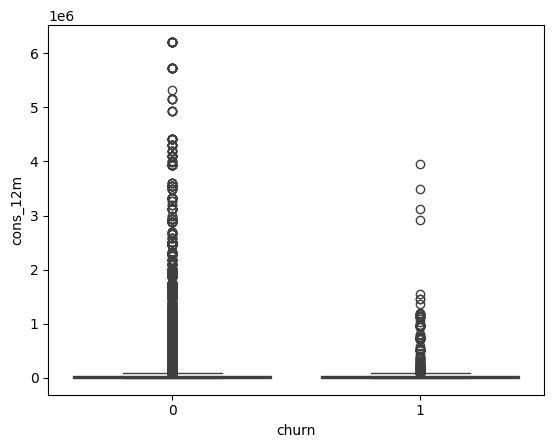

In [14]:
sns.boxplot(x="churn",y="cons_12m",data=df_client)

Customers who churn tend to have lower electricity consumption compared to retained customers. High-consumption customers appear less likely to churn.

In [15]:
churned["forecast_price_energy_peak"].mean()

np.float64(0.05487282804792107)

In [16]:
retained["forecast_price_energy_peak"].mean()

np.float64(0.05001923128839007)

<Axes: xlabel='churn', ylabel='forecast_price_energy_peak'>

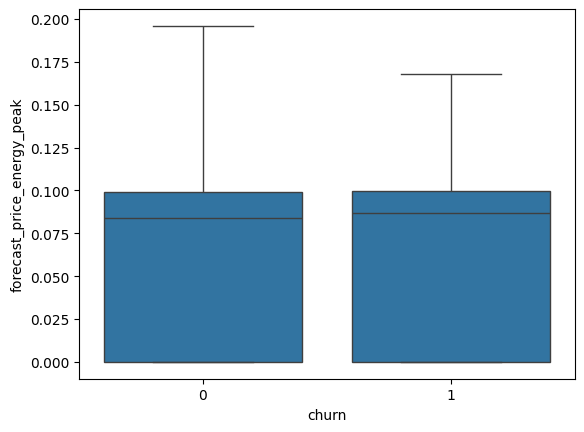

In [17]:
sns.boxplot(x="churn",y="forecast_price_energy_peak",data=df_client)

The distribution of forecasted peak energy prices appears very similar between churned and retained customers, suggesting that price alone may not be a strong standalone predictor of churn.

<Figure size 1800x1600 with 0 Axes>

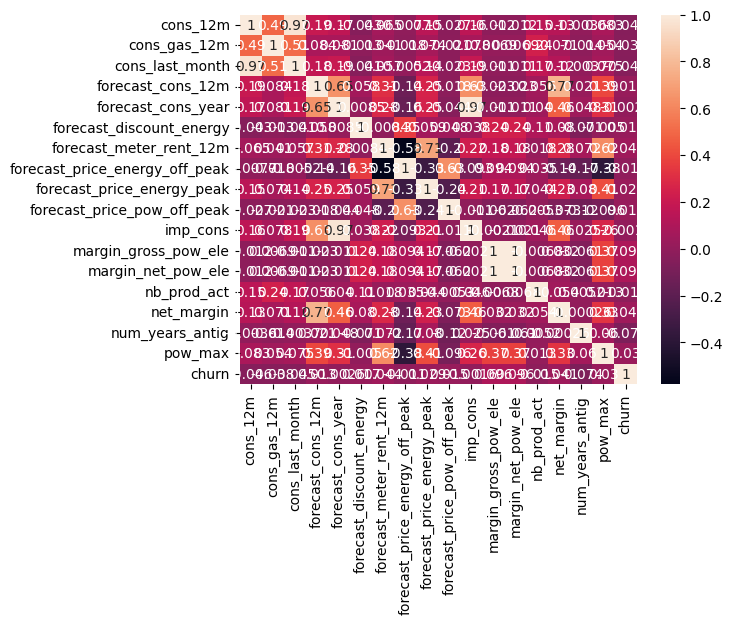

<Figure size 1800x1600 with 0 Axes>

In [18]:
sns.heatmap(df_client.select_dtypes(include=[int,float]).corr(),
            annot=True,
            )
plt.figure(figsize=(18,16))

In [19]:
df_client.duplicated().sum()

np.int64(0)

In [20]:
df_price.duplicated().sum()

np.int64(0)

In [21]:
df_client.info()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  str    
 1   channel_sales                   14606 non-null  str    
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  str    
 6   date_end                        14606 non-null  str    
 7   date_modif_prod                 14606 non-null  str    
 8   date_renewal                    14606 non-null  str    
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         14606 non-n

In [22]:
date_colmns=["date_activ","date_end","date_modif_prod","date_renewal"]

In [23]:
df_client[date_colmns]=df_client[date_colmns].apply(pd.to_datetime)

In [24]:
df_client["has_gas"]=df_client["has_gas"].map({"t":1,"f":0})

In [25]:
df_client=pd.get_dummies(df_client,columns=['channel_sales','origin_up'])

In [26]:
df_client=df_client.drop(columns=["id"])

Tenure

In [27]:
df_client["tenure_days"]=(df_client["date_end"]-df_client["date_activ"]).dt.days

last modification

In [28]:
df_client["days_since_mod"]=(df_client["date_end"]-df_client["date_modif_prod"]).dt.days

Renewal gap

In [29]:
df_client["days_to_renewal"]=(df_client["date_renewal"]-df_client["date_end"]).dt.days

drop raw dates

In [ ]:
df_client=df_client.drop(columns=[date_colmns])